# 반송 지연 예측 — 요청 시점 정보로 Cycle Time 예측

`amhs/simulation.py`로 차량 대수/투입 간격을 다양하게 바꿔가며 여러 번 시뮬레이션을 돌리고, 그 반송 로그로 **"반송 요청이 들어온 순간, 그 반송이 얼마나 걸릴지(그리고 지연 위험이 있는지)"**를 예측하는 모델을 만든다. MCS가 실시간으로 참고할 수 있는 정보(요청 시점의 시스템 부하, 출발/도착 스테이션)만 피처로 쓴다 — 반송이 끝난 뒤에나 알 수 있는 정보(실제 걸린 시간 등)는 당연히 제외.

**검증 방식**: 시뮬레이션 설정(차량 대수 x 투입 간격) 조합별로 여러 런을 돌리고, **일부 설정 조합 전체를 test로 떼어내는 방식**(run-level split)으로 검증한다 — 같은 조합 안에서 무작위로 나누면 모델이 그냥 그 조합의 평균 부하 수준을 외우기만 해도 성능이 잘 나오는 것처럼 보일 수 있어서, **본 적 없는 부하 조건에도 일반화하는지**를 보려는 것이다.

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from xgboost import XGBRegressor, XGBClassifier

from amhs import STATION_ORDER, STATIONS, run_simulation, nearest_vehicle_dispatch, travel_time_seconds

RANDOM_STATE = 42
MODELS_DIR = ROOT_DIR / "models"

## 1. 다양한 부하 조건으로 시뮬레이션 데이터 생성

차량 대수(3~8대) x FOUP 투입 간격(80~220초) 조합마다 시드를 바꿔 2회씩 실행 — 조합마다 부하 수준이 다르므로 cycle time의 분산이 커지고, 모델이 배울 신호가 생긴다.

In [2]:
vehicle_options = [3, 4, 5, 6, 8]
interval_options = [80.0, 120.0, 150.0, 200.0, 220.0]
seeds_per_config = [0, 1]

all_logs = []
run_id = 0
for n_vehicles in vehicle_options:
    for interval in interval_options:
        for seed in seeds_per_config:
            result = run_simulation(
                n_vehicles=n_vehicles, n_foups=20, n_laps=2,
                foup_launch_interval_sec=interval,
                dispatch_policy=nearest_vehicle_dispatch,
                seed=100 * n_vehicles + seed,
            )
            log = result["transport_log"].copy()
            log["run_id"] = run_id
            log["n_vehicles"] = n_vehicles
            log["launch_interval_sec"] = interval
            all_logs.append(log)
            run_id += 1

full_log = pd.concat(all_logs, ignore_index=True)
print(f"{run_id}개 런, 총 {len(full_log)}건 반송")
print(full_log["cycle_time_sec"].describe())

50개 런, 총 15992건 반송
count    15992.000000
mean       317.123957
std        307.447840
min         52.363636
25%         52.363636
50%        197.818182
75%        513.509032
max       1309.298271
Name: cycle_time_sec, dtype: float64


## 2. 피처 엔지니어링

요청 시점에 알 수 있는 정보만 쓴다:
- `from_idx`, `to_idx`: 출발/도착 스테이션
- `direct_travel_time`: 두 스테이션 사이 정적 이동 시간(거리/속도) — 정체가 전혀 없을 때의 최소 시간
- `concurrent_requests`: 이 요청이 생성된 순간, 아직 완료되지 않은 다른 반송이 몇 건 진행 중이었는지 — **실시간 시스템 부하**
- `n_vehicles`, `launch_interval_sec`: 그 시점의 설정값(실시간 MCS라면 알고 있는 값)

In [3]:
def add_concurrent_requests(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("requested_at").reset_index(drop=True)
    req = df["requested_at"].to_numpy()
    comp = df["completed_at"].to_numpy()
    # 각 요청 i에 대해, j != i 이면서 req[j] <= req[i] < comp[j] 인 j의 개수
    concurrent = ((req[None, :] <= req[:, None]) & (req[:, None] < comp[None, :])).sum(axis=1) - 1
    df["concurrent_requests"] = concurrent
    return df


full_log = pd.concat(
    [add_concurrent_requests(g) for _, g in full_log.groupby("run_id")],
    ignore_index=True,
)

full_log["from_idx"] = full_log["from"].map(lambda s: STATIONS[s].index)
full_log["to_idx"] = full_log["to"].map(lambda s: STATIONS[s].index)
full_log["direct_travel_time"] = full_log.apply(lambda r: travel_time_seconds(r["from"], r["to"]), axis=1)

FEATURES = ["from_idx", "to_idx", "direct_travel_time", "concurrent_requests", "n_vehicles", "launch_interval_sec"]
full_log[FEATURES + ["cycle_time_sec", "run_id"]].head()

,from_idx,to_idx,direct_travel_time,concurrent_requests,n_vehicles,launch_interval_sec,cycle_time_sec,run_id
0,0,1,36.363636,0,3,80.0,52.363636,0
1,0,1,36.363636,0,3,80.0,270.545455,0
2,1,2,36.363636,1,3,80.0,52.363636,0
3,0,1,36.363636,1,3,80.0,270.545455,0
4,2,3,36.363636,1,3,80.0,88.727273,0


## 3. Run-level Train/Test 분리

전체 run_id 중 20%를 test로 완전히 떼어낸다 — test에 쓰인 (차량 대수, 투입 간격) 조합은 학습에 전혀 등장하지 않는다.

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
unique_runs = full_log["run_id"].unique()
test_runs = rng.choice(unique_runs, size=max(1, int(len(unique_runs) * 0.2)), replace=False)

train_df = full_log[~full_log["run_id"].isin(test_runs)]
test_df = full_log[full_log["run_id"].isin(test_runs)]

print(f"train: {len(train_df)}건 ({train_df['run_id'].nunique()}개 런)")
print(f"test:  {len(test_df)}건 ({test_df['run_id'].nunique()}개 런)")
print("test에 쓰인 (차량대수, 투입간격) 조합:")
print(test_df[["n_vehicles", "launch_interval_sec"]].drop_duplicates())

train: 12792건 (40개 런)
test:  3200건 (10개 런)
test에 쓰인 (차량대수, 투입간격) 조합:
       n_vehicles  launch_interval_sec
952             3                120.0
1272            3                150.0
2872            3                220.0
6072            4                220.0
8952            5                220.0
10232           6                120.0
12472           6                220.0
14072           8                150.0
15672           8                220.0


## 4. Cycle Time 회귀

In [5]:
X_train, y_train = train_df[FEATURES], train_df["cycle_time_sec"]
X_test, y_test = test_df[FEATURES], test_df["cycle_time_sec"]

reg = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print(f"MAE: {mae:.1f}초 (test 평균 cycle time {y_test.mean():.1f}초 대비 {mae/y_test.mean():.1%})")
print(f"R²: {r2:.4f}")

MAE: 57.7초 (test 평균 cycle time 307.3초 대비 18.8%)
R²: 0.9325


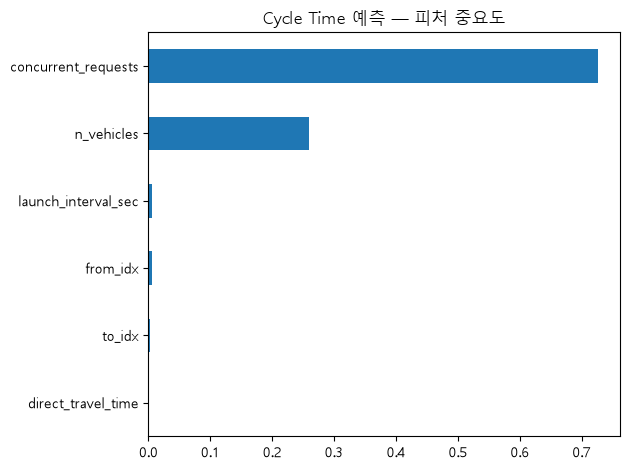

concurrent_requests    0.725633
n_vehicles             0.260044
launch_interval_sec    0.005792
from_idx               0.005445
to_idx                 0.003085
direct_travel_time     0.000000
dtype: float32

In [6]:
importances = pd.Series(reg.feature_importances_, index=FEATURES).sort_values(ascending=False)
importances.plot(kind="barh")
plt.title("Cycle Time 예측 — 피처 중요도")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
importances

## 5. 혼잡(지연) 위험 분류

학습셋(train) 기준 cycle time 75th 백분위수를 임계값으로 잡아 '지연' 여부를 이진 분류한다. 임계값을 test로 정하지 않는 이유는 03/04 노트북과 동일 — test 누출 방지.

In [7]:
delay_threshold = float(y_train.quantile(0.75))
print(f"지연 임계값(train 75th pct): {delay_threshold:.1f}초")

y_train_delay = (y_train > delay_threshold).astype(int)
y_test_delay = (y_test > delay_threshold).astype(int)
print("train 지연 비율:", y_train_delay.mean().round(4), " test 지연 비율:", y_test_delay.mean().round(4))

clf = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    eval_metric="logloss", random_state=RANDOM_STATE,
)
clf.fit(X_train, y_train_delay)
proba = clf.predict_proba(X_test)[:, 1]
pred_delay = (proba >= 0.5).astype(int)

print(f"F1: {f1_score(y_test_delay, pred_delay):.4f}")
print(f"Precision: {precision_score(y_test_delay, pred_delay):.4f}")
print(f"Recall: {recall_score(y_test_delay, pred_delay):.4f}")
print(f"AUROC: {roc_auc_score(y_test_delay, proba):.4f}")

지연 임계값(train 75th pct): 507.5초
train 지연 비율: 0.25  test 지연 비율: 0.2706
F1: 0.9471
Precision: 0.9328
Recall: 0.9619
AUROC: 0.9957


## 6. 저장

In [8]:
import joblib
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(reg, MODELS_DIR / "amhs_delay_regressor.joblib")
joblib.dump(clf, MODELS_DIR / "amhs_delay_classifier.joblib")
joblib.dump(FEATURES, MODELS_DIR / "amhs_delay_features.joblib")
joblib.dump(delay_threshold, MODELS_DIR / "amhs_delay_threshold.joblib")

summary = pd.DataFrame([{
    "mae_sec": round(mae, 2),
    "mae_pct_of_mean": round(mae / y_test.mean(), 4),
    "r2": round(r2, 4),
    "delay_f1": round(f1_score(y_test_delay, pred_delay), 4),
    "delay_precision": round(precision_score(y_test_delay, pred_delay), 4),
    "delay_recall": round(recall_score(y_test_delay, pred_delay), 4),
    "delay_auroc": round(roc_auc_score(y_test_delay, proba), 4),
}])
summary.to_csv(MODELS_DIR / "amhs_delay_prediction_results.csv", index=False)
summary

,mae_sec,mae_pct_of_mean,r2,delay_f1,delay_precision,delay_recall,delay_auroc
0,57.75,0.1879,0.9325,0.9471,0.9328,0.9619,0.9957


## 결론

실행 결과(위 출력)를 보고 채운다. 기대할 수 있는 패턴: `concurrent_requests`(요청 시점 시스템 부하)가 `direct_travel_time`(정적 거리)보다 훨씬 중요한 피처로 나온다면, **반송 지연은 레이아웃(거리)보다 그 순간의 혼잡도가 좌우한다**는 뜻이고, 이는 실제 fab에서도 통하는 직관이다(거리는 고정이지만 부하는 시시각각 바뀐다). run-level split으로도 합리적인 R²/F1이 나온다면, 이 모델이 본 적 없는 (차량 대수, 투입 간격) 조합에도 어느 정도 일반화된다는 뜻 — 실제 MCS라면 이런 모델로 "이 반송은 지연될 가능성이 높으니 우선순위를 올리자" 같은 판단을 실시간으로 도울 수 있다.